# Medan Magnet pada Bahan-bahan

**Elektrodinamika Klasik - Bab 6 Griffiths, edisi ke-4**

Notebook ini membangun penjelasan secara berurutan: model dipol magnetik → magnetisasi → arus terikat → medan bantu $\mathbf H$ → respons bahan linear dan feromagnetik. Setiap diagram digambar ulang khusus untuk notebook ini; tidak ada gambar buku yang disalin.

Semua arah vektor ditentukan dari sistem koordinat yang dinyatakan pada gambar. Notasi tebal atau panah menyatakan vektor, sedangkan subskrip seperti $B_x$ menyatakan komponen skalar. Rujukan memakai nomor halaman cetak buku: Bab 6, hlm. 266–295.

## 1. Notasi

Momen dipol magnetik $\mathbf m$ diukur dalam A m$^2$. Magnetisasi $\mathbf M$ adalah momen dipol per volume (A/m). Medan magnet $\mathbf B$ memiliki satuan tesla; medan bantu $\mathbf H$ dan magnetisasi $\mathbf M$ sama-sama bersatuan A/m, tetapi mempunyai definisi dan peran yang berbeda.

Arus bebas $\mathbf J_f$ adalah arus transport yang dialirkan dari luar. Arus terikat $\mathbf J_b$ dan $\mathbf K_b$ merupakan representasi makroskopik efek kolektif dipol mikroskopik. Vektor normal permukaan $\hat{\mathbf n}$ selalu didefinisikan **keluar dari bahan** pada rumus arus terikat.

| Bagian | Pertanyaan utama | Hasil |
|---|---|---|
| 6.1 | Bagaimana dipol merespons medan dan bagaimana bahan menjadi termagnetisasi? | $\mathbf N$, $\mathbf F$, $\mathbf M$ |
| 6.2 | Bagaimana menghitung medan dari magnetisasi? | $\mathbf J_b=\nabla\times\mathbf M$, $\mathbf K_b=\mathbf M\times\hat{\mathbf n}$ |
| 6.3 | Bagaimana memisahkan kontribusi arus bebas dari magnetisasi? | $\mathbf H=\mathbf B/\mu_0-\mathbf M$ |
| 6.4 | Bagaimana bahan merespons medan luar? | $\mathbf M=\chi_m\mathbf H$, $\mathbf B=\mu\mathbf H$ |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Rectangle

%config InlineBackend.figure_formats = ['svg']

mu0 = 4 * np.pi * 1e-7  # N/A^2; nilai konvensional yang digunakan Griffiths edisi ke-4
plt.rcParams.update({"figure.figsize": (8, 5), "font.size": 11})
print(f"mu0 = {mu0:.6g} N/A^2")

mu0 = 1.25664e-06 N/A^2


## 2. Dipol Magnetik (Torsi dan Gaya)

Loop arus kecil memiliki momen dipol $\mathbf m=IA\hat{\mathbf n}$, dengan $\hat{\mathbf n}$ menurut aturan tangan kanan terhadap arah arus. Untuk medan seragam, resultan gaya pada loop tertutup nol, tetapi torsi umumnya tidak nol:

$$\mathbf N=\mathbf m\times\mathbf B,\qquad |\mathbf N|=mB\sin\theta.$$

Vektor output torsi tegak lurus bidang yang dibentuk $\mathbf m$ dan $\mathbf B$; torsi cenderung memutar $\mathbf m$ agar sejajar dengan $\mathbf B$. Dalam medan tak seragam, dipol ideal mengalami gaya

$$\mathbf F=(\mathbf m\cdot\nabla)\mathbf B.$$

Di daerah bebas arus di sekitar dipol, ini sama dengan $\nabla(\mathbf m\cdot\mathbf B)$. Karena itu medan seragam dapat memberi torsi tanpa gaya translasi, sedangkan gradien medan dapat menarik atau menolak dipol. (Griffiths §6.1.2, hlm. 267–269.)

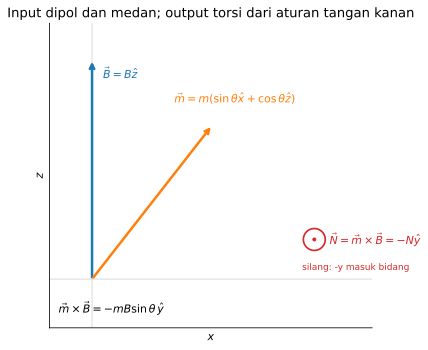

In [2]:
# Proyeksi bidang x-z: B sepanjang +z, m miring dari +z menuju +x.
# Maka m x B menunjuk -y, masuk bidang gambar.
fig, ax = plt.subplots(figsize=(7.5, 5.5))
ax.set_aspect("equal"); ax.set_xlim(-0.7, 4.6); ax.set_ylim(-0.8, 4.2)
ax.axhline(0, color="0.85", lw=1); ax.axvline(0, color="0.85", lw=1)
ax.annotate("", (0, 3.6), (0, 0), arrowprops={"arrowstyle": "->", "lw": 2.5, "color": "C0"})
ax.text(0.18, 3.3, r"$\vec B=B\hat z$", color="C0")
theta = np.deg2rad(38)
ax.annotate("", (3.2*np.sin(theta), 3.2*np.cos(theta)), (0, 0), arrowprops={"arrowstyle": "->", "lw": 2.5, "color": "C1"})
ax.text(1.35, 2.9, r"$\vec m=m(\sin\theta\hat x+\cos\theta\hat z)$", color="C1")
ax.add_patch(Circle((3.65, 0.65), 0.18, fill=False, color="C3", lw=1.7)); ax.plot(3.65, 0.65, ".", color="C3", ms=6)
ax.text(3.9, 0.65, r"$\vec N=\vec m\times\vec B=-N\hat y$", color="C3", va="center")
ax.text(3.45, 0.15, "silang: -y masuk bidang", fontsize=9, color="C3")
ax.text(-0.55, -0.55, r"$\vec m\times\vec B=-mB\sin\theta\,\hat y$", fontsize=11)
ax.set_xlabel(r"$x$"); ax.set_ylabel(r"$z$"); ax.set_title("Input dipol dan medan; output torsi dari aturan tangan kanan")
ax.set_xticks([]); ax.set_yticks([]); ax.spines[["top", "right"]].set_visible(False)
plt.show()

### Penurunan torsi dari loop persegi panjang

Ambil loop berarus $I$, sisi $a$ dan $b$, dengan normal $\hat{\mathbf n}$ membentuk sudut $\theta$ terhadap $\mathbf B$. Pada setiap segmen gunakan hukum gaya arus $d\mathbf F=I\,d\boldsymbol\ell\times\mathbf B$. Gaya pada dua sisi yang tegak lurus sumbu putar sama besar dan berlawanan, sehingga resultannya nol, tetapi membentuk pasangan gaya. Lengan momen tegak lurus menghasilkan

$$N=(bF)\sin\theta=(b)(IaB)\sin\theta=IabB\sin\theta.$$

Karena luas loop $A=ab$ dan $m=IA$, besar torsi adalah $mB\sin\theta$. Arah vektor tidak ditetapkan oleh gambar proyeksi semata: hitung $\mathbf m\times\mathbf B$ dengan urutan input tersebut. (Griffiths §6.1.2, hlm. 266–268.)

## 3. Magnetisasi dan Jenis Respons Bahan

Pada skala atom, arus elektron dan spin elektron berperilaku seperti dipol-dipol kecil. Jika momen-momen itu saling meniadakan, magnetisasi makroskopik nol; jika ada orientasi rata-rata, definisikan

$$\mathbf M=\frac{d\mathbf m_{\rm total}}{d\tau},\qquad [\mathbf M]=\mathrm{A/m}.$$

- **Paramagnetik:** dipol cenderung sejajar medan terapan; $\mathbf M$ searah $\mathbf B$ dan biasanya hilang saat medan dihilangkan.
- **Diamagnetik:** medan menginduksi perubahan dipol yang menentang medan; $\mathbf M$ berlawanan arah $\mathbf B$. Respons ini lemah dan terjadi pada semua bahan, tetapi sering tertutupi paramagnetisme.
- **Feromagnetik:** interaksi antar-dipol membuat domain-domain teratur; magnetisasi dapat bertahan setelah medan luar dilepas dan bergantung pada riwayat bahan.

Klasifikasi ini menentukan arah respons, bukan aturan bahwa $\mathbf M$ selalu searah $\mathbf H$ untuk semua bahan. Feromagnet tidak dijelaskan dengan satu suseptibilitas konstan. (Griffiths 6.1.1 dan 6.1.4, hlm. 266, 273–274.)

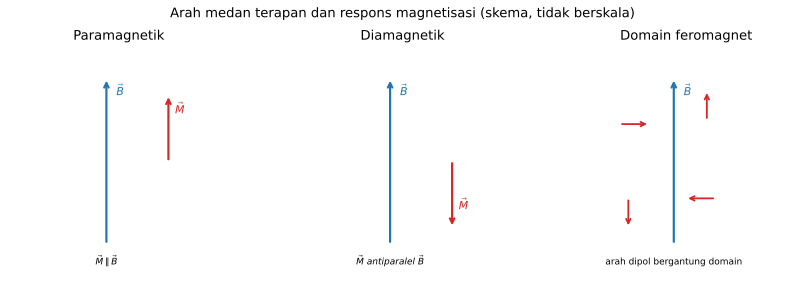

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
cases = [(1, "Paramagnetik", r"$\vec M\parallel\vec B$"), (-1, "Diamagnetik", r"$\vec M\ antiparalel\ \vec B$"), (0, "Domain feromagnet", "arah dipol bergantung domain")]
for ax, (sign, title, note) in zip(axes, cases):
    ax.set_aspect("equal"); ax.set_xlim(-1.2, 1.5); ax.set_ylim(-1.4, 1.4)
    ax.annotate("", (0, 1.0), (0, -1.0), arrowprops={"arrowstyle": "->", "lw": 2.2, "color": "C0"})
    ax.text(0.12, 0.8, r"$\vec B$", color="C0")
    if sign:
        ax.annotate("", (0.75, 0.8*sign), (0.75, 0), arrowprops={"arrowstyle": "->", "lw": 2.2, "color": "C3"})
        ax.text(0.83, 0.58*sign, r"$\vec M$", color="C3")
    else:
        for x, y, dx, dy in [(-0.65, 0.45, 0.35, 0), (0.4, 0.5, 0, 0.35), (-0.55, -0.45, 0, -0.35), (0.5, -0.45, -0.35, 0)]:
            ax.annotate("", (x+dx, y+dy), (x, y), arrowprops={"arrowstyle": "->", "lw": 1.8, "color": "C3"})
    ax.set_title(title); ax.text(0, -1.25, note, ha="center", fontsize=9)
    ax.axis("off")
fig.suptitle("Arah medan terapan dan respons magnetisasi (skema, tidak berskala)")
plt.tight_layout(); plt.show()

## 4. Dari magnetisasi ke arus terikat

Sebuah elemen volume termagnetisasi $d\tau'$ memiliki momen $d\mathbf m=\mathbf M(\mathbf r')d\tau'$. Potensial vektor kumpulan dipol adalah

$$\mathbf A(\mathbf r)=\frac{\mu_0}{4\pi}\int \frac{\mathbf M(\mathbf r')\times\hat{\mathbf R}}{R^2}\,d\tau',\qquad \mathbf R=\mathbf r-\mathbf r'.$$

Dengan identitas $\hat{\mathbf R}/R^2=\nabla'(1/R)$ dan integrasi parsial, kontribusi volume berubah menjadi potensial arus volume, sementara suku permukaan berubah menjadi potensial arus permukaan. Maka sumber ekuivalennya adalah

$$\boxed{\mathbf J_b=\nabla\times\mathbf M},\qquad \boxed{\mathbf K_b=\mathbf M\times\hat{\mathbf n}}.$$

Arah cross product penting: normal $\hat{\mathbf n}$ keluar bahan, dan urutan inputnya $\mathbf M$ dahulu lalu $\hat{\mathbf n}$. Arus mikroskopik di bagian dalam cenderung saling meniadakan; pada tepi permukaan tersisa arus bersih. Magnetisasi seragam memberi $\mathbf J_b=0$ di interior, tetapi umumnya masih memiliki $\mathbf K_b$ pada batas. (Griffiths §6.2.1–6.2.2, hlm. 274–279.)

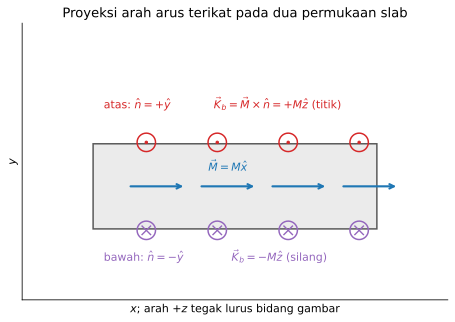

In [4]:
# Slab pada bidang xy: M=+M xhat dan normal permukaan atas n=+yhat.
# Kb=M x n=+z (titik/keluar bidang); di bawah Kb=-z (silang/masuk).
fig, ax = plt.subplots(figsize=(8, 5))
ax.set_aspect("equal"); ax.set_xlim(-0.5, 5.5); ax.set_ylim(-1.6, 2.3)
ax.add_patch(Rectangle((0.5, -0.6), 4, 1.2, facecolor="0.92", edgecolor="0.35", lw=1.5))
for x in [1.25, 2.25, 3.25, 4.25]:
    ax.annotate("", (x+0.55, 0), (x-0.25, 0), arrowprops={"arrowstyle": "->", "lw": 2.1, "color": "C0"})
ax.text(2.4, 0.22, r"$\vec M=M\hat x$", color="C0", ha="center")
for x in [1.25, 2.25, 3.25, 4.25]:
    ax.add_patch(Circle((x, 0.62), 0.13, fill=False, color="C3", lw=1.5)); ax.plot(x, 0.62, ".", color="C3", ms=5)
    ax.add_patch(Circle((x, -0.62), 0.13, fill=False, color="C4", lw=1.5))
    ax.plot([x-0.06, x+0.06], [-0.68, -0.56], color="C4", lw=1.4); ax.plot([x-0.06, x+0.06], [-0.56, -0.68], color="C4", lw=1.4)
ax.text(0.65, 1.1, r"atas: $\hat n=+\hat y$", color="C3")
ax.text(2.2, 1.1, r"$\vec K_b=\vec M\times\hat n=+M\hat z$ (titik)", color="C3")
ax.text(0.65, -1.05, r"bawah: $\hat n=-\hat y$", color="C4")
ax.text(2.45, -1.05, r"$\vec K_b=-M\hat z$ (silang)", color="C4")
ax.set_xlabel(r"$x$; arah $+z$ tegak lurus bidang gambar"); ax.set_ylabel(r"$y$")
ax.set_title("Proyeksi arah arus terikat pada dua permukaan slab")
ax.set_xticks([]); ax.set_yticks([]); ax.spines[["top", "right"]].set_visible(False)
plt.show()

### Contoh turunan - bola bermagnetisasi seragam

Ambil bola berjari-jari $R$ dengan $\mathbf M=M\hat{\mathbf z}$ konstan. Di volume, $\nabla\times\mathbf M=0$, jadi $\mathbf J_b=0$. Di permukaan bola, $\hat{\mathbf n}=\hat{\mathbf r}$ dan $\hat{\mathbf z}\times\hat{\mathbf r}=\sin\theta\hat{\boldsymbol\phi}$, sehingga

$$\mathbf K_b=M\sin\theta\,\hat{\boldsymbol\phi}.$$

Arus permukaan ini sama polanya dengan arus pada kulit bola berputar. Hasil medan (Griffiths Eq. 6.16):

$$\mathbf B_{\rm dalam}=\frac{2}{3}\mu_0M\hat{\mathbf z},\qquad \mathbf m_{\rm total}=\frac{4\pi R^3}{3}M\hat{\mathbf z}.$$

Di luar bola, medannya adalah medan dipol dengan momen $\mathbf m_{\rm total}$:

$$\mathbf B_{\rm luar}(\mathbf r)=\frac{\mu_0}{4\pi r^3}\left[3(\mathbf m_{\rm total}\cdot\hat{\mathbf r})\hat{\mathbf r}-\mathbf m_{\rm total}\right].$$

Kita memperoleh input arus dari $\mathbf M\times\hat{\mathbf n}$, lalu output medan dari arus tersebut. (Griffiths §6.2.1, hlm. 275–276.)

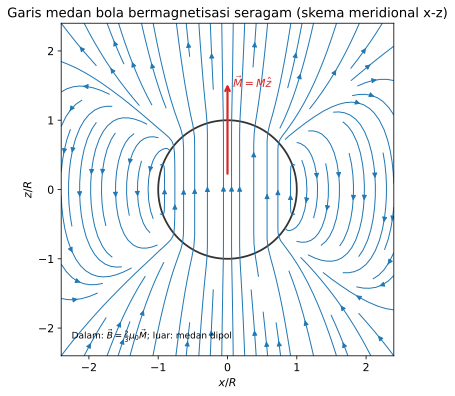

In [5]:
Rball, M0 = 1.0, 1.0
fig, ax = plt.subplots(figsize=(7, 6))
x = np.linspace(-2.4, 2.4, 33); z = np.linspace(-2.4, 2.4, 33)
X, Z = np.meshgrid(x, z); rr2 = X**2 + Z**2; rr = np.sqrt(rr2)
inside = rr < Rball
Bx = np.zeros_like(X); Bz = np.zeros_like(Z)
Bx[inside] = 0
Bz[inside] = 2*mu0*M0/3
outside = ~inside
Bx[outside] = 3*mu0*M0*Rball**3*X[outside]*Z[outside]/(4*np.maximum(rr[outside]**5, 1e-9))
Bz[outside] = mu0*M0*Rball**3*(3*Z[outside]**2/np.maximum(rr[outside]**5, 1e-9)-1/np.maximum(rr[outside]**3, 1e-9))
ax.streamplot(X, Z, Bx, Bz, density=1.0, color="C0", linewidth=1)
ax.add_patch(Circle((0, 0), Rball, fill=False, color="0.2", lw=1.8))
ax.annotate("", (0, 1.55), (0, 0.2), arrowprops={"arrowstyle": "->", "lw": 2.2, "color": "C3"})
ax.text(0.08, 1.48, r"$\vec M=M\hat z$", color="C3")
ax.text(-2.25, -2.15, r"Dalam: $\vec B=\frac{2}{3}\mu_0\vec M$; luar: medan dipol", fontsize=9)
ax.set_aspect("equal"); ax.set_xlabel(r"$x/R$"); ax.set_ylabel(r"$z/R$")
ax.set_title("Garis medan bola bermagnetisasi seragam (skema meridional x-z)")
plt.show()

## 5. Medan bantu $\mathbf H$ dan arus bebas

Pisahkan rapat arus total menjadi arus bebas dan arus terikat:

$$\mathbf J=\mathbf J_f+\mathbf J_b=\mathbf J_f+\nabla\times\mathbf M.$$

Masukkan ke hukum Ampère mikroskopik $\nabla\times\mathbf B=\mu_0\mathbf J$, lalu kumpulkan curl:

$$\nabla\times\left(\frac{\mathbf B}{\mu_0}-\mathbf M\right)=\mathbf J_f.$$

Definisikan

$$\boxed{\mathbf H\equiv\frac{\mathbf B}{\mu_0}-\mathbf M},\qquad \nabla\times\mathbf H=\mathbf J_f,\qquad \oint_C\mathbf H\cdot d\boldsymbol\ell=I_{f,\rm enc}.$$

Hukum integral memakai arus **bebas** yang menembus permukaan sesuai normal berorientasi kaidah tangan kanan. Persamaan terakhir sangat berguna bila geometri memiliki simetri. Tetapi $\mathbf H$ bukan sekadar $\mathbf B/\mu_0$: untuk bahan termagnetisasi, kurangi $\mathbf M$. Selain itu, $\nabla\cdot\mathbf H=-\nabla\cdot\mathbf M$ umumnya tidak nol. Tidak adanya arus bebas hanya memberi $\nabla\times\mathbf H=0$; tidak otomatis menyatakan $\mathbf H=0$. (Griffiths §6.3.1–6.3.2, hlm. 279–284.)

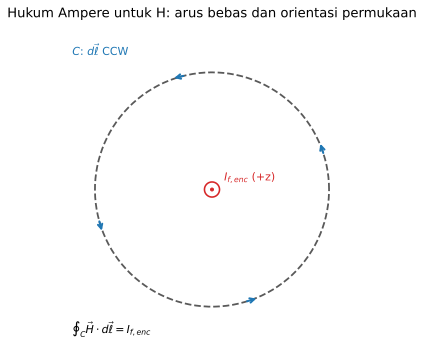

In [6]:
# Skema Amperian: normal +z (titik) dan arah integrasi CCW jika dilihat dari +z.
fig, ax = plt.subplots(figsize=(7, 6))
ax.set_aspect("equal"); ax.set_xlim(-2.2, 2.2); ax.set_ylim(-2.2, 2.2)
t = np.linspace(0, 2*np.pi, 240)
ax.plot(1.55*np.cos(t), 1.55*np.sin(t), "--", color="0.35", lw=1.8)
for angle in [0.3, 1.8, 3.4, 5.0]:
    x0, y0 = 1.55*np.cos(angle), 1.55*np.sin(angle)
    ax.annotate("", (x0-0.18*np.sin(angle), y0+0.18*np.cos(angle)), (x0, y0), arrowprops={"arrowstyle": "->", "color": "C0", "lw": 2})
ax.add_patch(Circle((0, 0), 0.1, fill=False, color="C3", lw=1.6)); ax.plot(0, 0, ".", color="C3", ms=6)
ax.text(0.16, 0.12, r"$I_{f,enc}$ (+z)", color="C3")
ax.text(-1.85, 1.78, r"$C$: $d\vec\ell$ CCW", color="C0")
ax.text(-1.85, -1.9, r"$\oint_C\vec H\cdot d\vec\ell=I_{f,enc}$", fontsize=11)
ax.set_xlabel(r"$x$"); ax.set_ylabel(r"$y$"); ax.set_title("Hukum Ampere untuk H: arus bebas dan orientasi permukaan")
ax.axis("off"); plt.show()

### Contoh — batang silinder panjang dengan arus bebas merata

Batang berjari-jari $R$ membawa arus bebas total $I$ sepanjang $+z$, terdistribusi merata. Simetri silinder menunjukkan $\mathbf H=H_\phi(s)\hat{\boldsymbol\phi}$. Pada lintasan Amperian radius $s<R$, arus yang terkurung adalah $I_{f,\rm enc}=I s^2/R^2$. Karena $\mathbf H$ sejajar lintasan dan konstan di keliling:

$$H_\phi(2\pi s)=I\frac{s^2}{R^2}\quad\Rightarrow\quad \mathbf H=\frac{Is}{2\pi R^2}\hat{\boldsymbol\phi},\quad s<R.$$

Untuk $s>R$, seluruh arus terkurung:

$$\mathbf H=\frac{I}{2\pi s}\hat{\boldsymbol\phi},\quad s>R.$$

Di luar bahan, $\mathbf M=0$ sehingga $\mathbf B=\mu_0\mathbf H$. Di dalam, $\mathbf B=\mu_0(\mathbf H+\mathbf M)$; tanpa hubungan bahan atau nilai $\mathbf M$, $\mathbf B$ belum ditentukan hanya dari arus bebas. (Griffiths §6.3.1, contoh 6.2, hlm. 280–282.)

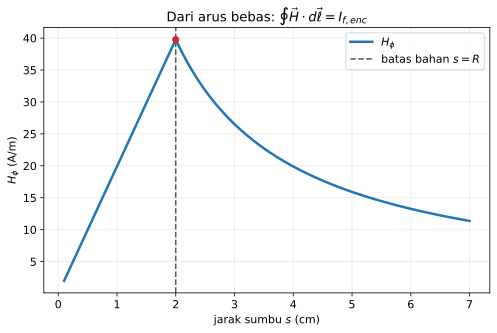

In [7]:
Rrod, Irod = 0.02, 5.0
s = np.linspace(0.001, 0.07, 400)
Hphi = np.where(s < Rrod, Irod*s/(2*np.pi*Rrod**2), Irod/(2*np.pi*s))
fig, ax = plt.subplots(figsize=(8, 4.8))
ax.plot(s*100, Hphi, color="C0", lw=2.5, label=r"$H_\phi$")
ax.axvline(Rrod*100, color="0.35", ls="--", label=r"batas bahan $s=R$")
ax.scatter([Rrod*100], [Irod/(2*np.pi*Rrod)], color="C3", zorder=3)
ax.set_xlabel(r"jarak sumbu $s$ (cm)"); ax.set_ylabel(r"$H_\phi$ (A/m)")
ax.set_title(r"Dari arus bebas: $\oint\vec H\cdot d\vec\ell=I_{f,enc}$")
ax.grid(alpha=0.3); ax.legend(); plt.show()

## 6. Syarat batas pada antarmuka bahan

Ambil normal $\hat{\mathbf n}$ dari medium 1 menuju medium 2. Dua hukum integral memberi syarat batas komponen medan:

$$\hat{\mathbf n}\cdot(\mathbf B_2-\mathbf B_1)=0,$$

jadi komponen normal $\mathbf B$ kontinu, dan

$$\hat{\mathbf n}\times(\mathbf H_2-\mathbf H_1)=\mathbf K_f,$$

dengan $\mathbf K_f$ arus bebas permukaan. Jika $\mathbf K_f=0$, komponen tangensial $\mathbf H$ kontinu. Komponen tangensial $\mathbf B$ tidak harus kontinu karena respons magnetisasi dapat berbeda pada kedua sisi. Untuk membaca tanda, jangan membalik normal di tengah perhitungan: semua indeks dan cross product mengikuti pilihan $1\to2$ yang sama. (Griffiths §6.3.3, hlm. 284.)

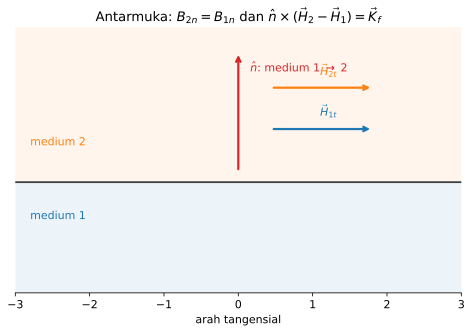

In [8]:
fig, ax = plt.subplots(figsize=(8, 4.8))
ax.set_xlim(-3, 3); ax.set_ylim(-1.5, 2.1)
ax.axhspan(-1.5, 0, color="C0", alpha=0.08); ax.axhspan(0, 2.1, color="C1", alpha=0.08)
ax.axhline(0, color="0.25", lw=1.8)
ax.annotate("", (0, 1.75), (0, 0.15), arrowprops={"arrowstyle": "->", "lw": 2.2, "color": "C3"})
ax.text(0.16, 1.5, r"$\hat n$: medium 1 $\to$ 2", color="C3")
ax.annotate("", (1.8, 0.72), (0.45, 0.72), arrowprops={"arrowstyle": "->", "lw": 2.2, "color": "C0"})
ax.text(1.1, 0.9, r"$\vec H_{1t}$", color="C0")
ax.annotate("", (1.8, 1.28), (0.45, 1.28), arrowprops={"arrowstyle": "->", "lw": 2.2, "color": "C1"})
ax.text(1.1, 1.45, r"$\vec H_{2t}$", color="C1")
ax.text(-2.8, -0.5, "medium 1", color="C0"); ax.text(-2.8, 0.5, "medium 2", color="C1")
ax.set_title(r"Antarmuka: $B_{2n}=B_{1n}$ dan $\hat n\times(\vec H_2-\vec H_1)=\vec K_f$")
ax.set_xlabel("arah tangensial"); ax.set_yticks([]); ax.spines[["left", "right", "top"]].set_visible(False)
plt.show()

## 7. Bahan linear: suseptibilitas dan permeabilitas

Untuk bahan isotropik linear pada medan yang tidak terlalu kuat, hubungan konstitutifnya adalah

$$\mathbf M=\chi_m\mathbf H,$$

dengan suseptibilitas magnetik $\chi_m$ tak berdimensi. Paramagnet memiliki $\chi_m>0$, diamagnet $\chi_m<0$. Substitusi ke $\mathbf B=\mu_0(\mathbf H+\mathbf M)$ memberi

$$\mathbf B=\mu_0(1+\chi_m)\mathbf H=\mu\mathbf H,\qquad \mu=\mu_0\mu_r,\quad \mu_r=1+\chi_m.$$

Ini berlaku untuk bahan linear homogen dan isotropik; bahan anisotropik membutuhkan tensor, sementara feromagnet umumnya nonlinear dan bergantung riwayat. Untuk solenoida panjang berisi bahan linear, hukum Ampère pada $\mathbf H$ memberi $\mathbf H=nI\hat{\mathbf z}$; baru setelahnya hubungan bahan menghasilkan $\mathbf B=\mu nI\hat{\mathbf z}$. (Griffiths §6.4.1, contoh 6.3, hlm. 285–287.)

Cu (diamagnetik, skala χ buku): H=200 A/m, B=0.000251325 T, M=-0.0018 A/m
Al (paramagnetik, skala χ buku): H=200 A/m, B=0.000251345 T, M=0.014 A/m


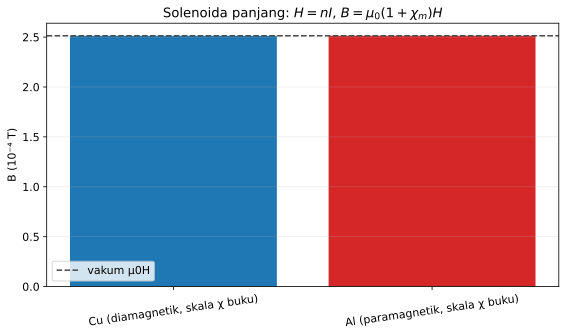

In [9]:
nturn, current = 800.0, 0.25
chi_values = [-9.0e-6, 7.0e-5]
labels = ["Cu (diamagnetik, skala χ buku)", "Al (paramagnetik, skala χ buku)"]
Hsol = nturn*current
fig, ax = plt.subplots(figsize=(8, 4.8))
for chi, label in zip(chi_values, labels):
    Bsol = mu0*(1+chi)*Hsol
    ax.bar(label, Bsol*1e4, color="C0" if chi < 0 else "C3")
    print(f"{label}: H={Hsol:.3g} A/m, B={Bsol:.6g} T, M={chi*Hsol:.3g} A/m")
ax.axhline(mu0*Hsol*1e4, color="0.3", ls="--", label="vakum μ0H")
ax.set_ylabel("B (10⁻⁴ T)"); ax.set_title(r"Solenoida panjang: $H=nI$, $B=\mu_0(1+\chi_m)H$")
ax.legend(); ax.tick_params(axis="x", labelrotation=8); ax.grid(axis="y", alpha=0.25); plt.tight_layout(); plt.show()

## 8. Feromagnet: domain dan histeresis

Dalam feromagnet, dipol di dalam domain cenderung sejajar; domain-domain yang berbeda dapat saling membatalkan sehingga benda tak termagnetisasi secara makroskopik. Medan luar menggeser batas domain: domain yang lebih sejajar medan membesar. Medan kuat dapat membawa bahan ke saturasi. Perubahan domain tidak sepenuhnya reversibel, sehingga saat medan dikembalikan ke nol masih tersisa magnetisasi (remanensi). Medan berlawanan diperlukan untuk menghilangkannya (koersivitas).

Kurva $B$–$H$ membentuk loop histeresis; nilai $B$ pada $H=0$ bergantung lintasan sebelumnya. Untuk feromagnet, $\chi_m$ atau $\mu$ bukan konstanta tunggal yang menjelaskan seluruh kurva. Diagram berikut **skematis**, bukan data eksperimen dari sumber. (Griffiths §6.4.2, hlm. 288–291.)

## 10. Problem dan solution

Latihan berikut ditulis ulang sebagai variasi mandiri berdasarkan konsep dan contoh Bab 6; bukan salinan teks soal. Rujukan Griffiths dicantumkan agar pembaca dapat menelusuri topik terkait.

### Problem 1 Torsi dan gaya pada dipol

Dipol $m=2.0\times10^{-3}\,\mathrm{A\,m^2}$ memiliki orientasi $\mathbf m=m(\sin30^\circ\hat{\mathbf x}+\cos30^\circ\hat{\mathbf z})$ dalam medan $\mathbf B(z)=(0.40+0.030z)\hat{\mathbf z}\,\mathrm T$, dengan $z$ dalam meter. Tentukan torsi dan gaya pada posisi $z=0$. (Griffiths ?6.1.2; terkait Problem 6.1 dan 6.4.)

**Solution.** Dengan $\mathbf N=\mathbf m\times\mathbf B$ dan $\hat{\mathbf x}\times\hat{\mathbf z}=-\hat{\mathbf y}$,

$$\mathbf N=-mB\sin30^\circ\hat{\mathbf y}=-4.0\times10^{-4}\hat{\mathbf y}\;\mathrm{N\,m}.$$

Karena $\mathbf F=(\mathbf m\cdot\nabla)\mathbf B=m_z(dB/dz)\hat{\mathbf z}$,

$$\mathbf F=m\cos30^\circ(0.030)\hat{\mathbf z}=5.2\times10^{-5}\hat{\mathbf z}\;\mathrm N.$$

### Problem 2 Silinder bermagnetisasi seragam

Silinder tak berhingga berjari-jari $a$ memiliki $\mathbf M=M_0\hat{\mathbf z}$. Tentukan arus terikat dan medan di dalam/luar. (Griffiths Problem 6.7.)

**Solution.** $\mathbf M$ seragam, sehingga $\mathbf J_b=\nabla\times\mathbf M=0$. Pada selimut, $\hat{\mathbf n}=\hat{\mathbf s}$ dan $\mathbf K_b=\mathbf M\times\hat{\mathbf n}=M_0\hat{\boldsymbol\phi}$. Pada ujung datar, $\hat{\mathbf n}=\pm\hat{\mathbf z}$ sehingga $\mathbf K_b=0$. Selimut adalah lembar arus solenoida ideal, maka

$$\mathbf B_{\rm in}=\mu_0M_0\hat{\mathbf z},\qquad \mathbf B_{\rm out}=0.$$

Akibatnya $\mathbf H=\mathbf B/\mu_0-\mathbf M=0$ baik di dalam maupun di luar.

### Problem 3 Bola linear di medan seragam

Bola bahan isotropik linear dengan suseptibilitas $\chi_m$ berada dalam medan luar seragam $\mathbf B_0$ (medan tanpa bola). Cari $\mathbf H$, $\mathbf M$, dan $\mathbf B$ di dalam. (Griffiths Problem 6.18.)

**Solution.** Definisikan $\mathbf H_0=\mathbf B_0/\mu_0$. Medan magnetisasi bola seragam di bagian dalam adalah $\mathbf B_{\rm mag}=+(2/3)\mu_0\mathbf M$. Jadi $\mathbf H_{\rm in}=\mathbf B_{\rm total}/\mu_0-\mathbf M=\mathbf H_0-\mathbf M/3$. Dengan $\mathbf M=\chi_m\mathbf H_{\rm in}$,

$$\mathbf H_{\rm in}=\frac{3}{3+\chi_m}\mathbf H_0,\qquad \mathbf M=\frac{3\chi_m}{3+\chi_m}\mathbf H_0,$$

$$\mathbf B_{\rm in}=\mu_0(\mathbf H_{\rm in}+\mathbf M)=\frac{3(1+\chi_m)}{3+\chi_m}\mathbf B_0.$$

Untuk $\chi_m=0$, hasil kembali $\mathbf B_{\rm in}=\mathbf B_0$.

### Problem 4 Solenoida berinti linear

Solenoida panjang memiliki $n=1.20\times10^3\,\mathrm{m^{-1}}$, $I=0.50\,\mathrm A$, dan inti dengan $\chi_m=2.0\times10^{-3}$. Hitung $H$, $M$, dan $B$. (Variasi numerik Griffiths contoh 6.3, ?6.4.1.)

**Solution.** Hukum Amp?re pada $\mathbf H$ memberi $H=nI=600\,\mathrm{A/m}$. Maka $M=\chi_mH=1.2\,\mathrm{A/m}$ dan

$$B=\mu_0(H+M)=\mu_0(1+\chi_m)H=7.55\times10^{-4}\,\mathrm T.$$

Ketiga vektor searah sumbu solenoida menurut kaidah tangan kanan arus.

### Problem 5 Arus terikat pada kawat lurus

Kawat panjang radius $a$ membawa arus bebas seragam $I$ ke arah $+z$ dan terbuat dari bahan linear dengan $\chi_m$. Tentukan $\mathbf H$, $\mathbf B$, dan arus terikat. (Variasi Griffiths Problem 6.17.)

**Solution.** Hukum Amp?re untuk arus bebas menghasilkan

$$\mathbf H=\begin{cases}\dfrac{Is}{2\pi a^2}\hat{\boldsymbol\phi},&s<a,\\[3pt]\dfrac{I}{2\pi s}\hat{\boldsymbol\phi},&s\ge a.\end{cases}$$

Di dalam kawat, $\mathbf M=\chi_m\mathbf H$ dan $\mathbf B=\mu_0(1+\chi_m)\mathbf H$; di luar, $\mathbf M=0$ dan $\mathbf B=\mu_0\mathbf H$. Karena $M_\phi=\chi_mIs/(2\pi a^2)$,

$$\mathbf J_b=\frac{1}{s}\frac{d(sM_\phi)}{ds}\hat{\mathbf z}=\frac{\chi_mI}{\pi a^2}\hat{\mathbf z},\qquad (s<a).$$

Pada selimut $s=a$, $\mathbf K_b=\mathbf M\times\hat{\mathbf s}=-\chi_mI/(2\pi a)\hat{\mathbf z}$ sebab $\hat{\boldsymbol\phi}\times\hat{\mathbf s}=-\hat{\mathbf z}$. Arus terikat volume terintegrasi $+\chi_mI$ dan arus permukaan $-\chi_mI$, jadi arus terikat bersih nol.


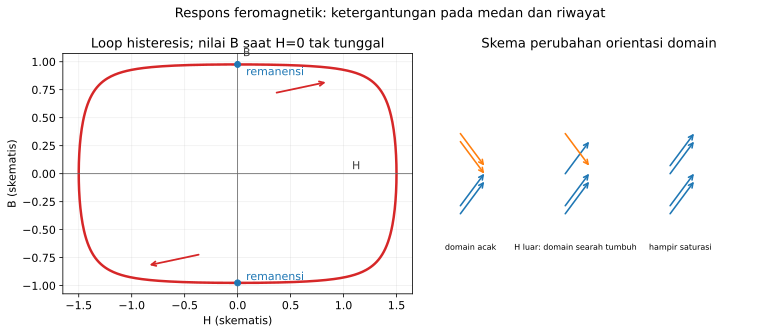

In [10]:
# Loop persegi membulat sebagai skema; skala tidak mewakili bahan tertentu.
t = np.linspace(0, 2*np.pi, 500)
Hnorm = 1.5*np.cos(t); Bnorm = np.tanh(2.2*np.sin(t))
fig, axes = plt.subplots(1, 2, figsize=(11, 4.7))
ax = axes[0]
ax.plot(Hnorm, Bnorm, color="C3", lw=2.5)
ax.axhline(0, color="0.4", lw=0.8); ax.axvline(0, color="0.4", lw=0.8)
ax.annotate("", (0.85, 0.82), (0.35, 0.72), arrowprops={"arrowstyle": "->", "color": "C3", "lw": 1.8})
ax.annotate("", (-0.85, -0.82), (-0.35, -0.72), arrowprops={"arrowstyle": "->", "color": "C3", "lw": 1.8})
ax.scatter([0, 0], [np.tanh(2.2), -np.tanh(2.2)], color="C0", zorder=3)
ax.text(0.08, 0.88, "remanensi", color="C0"); ax.text(0.08, -0.95, "remanensi", color="C0")
ax.text(1.08, 0.04, "H", color="0.25"); ax.text(0.05, 1.05, "B", color="0.25")
ax.set_xlabel("H (skematis)"); ax.set_ylabel("B (skematis)"); ax.set_title("Loop histeresis; nilai B saat H=0 tak tunggal")
ax.grid(alpha=0.2)
ax = axes[1]; ax.set_xlim(0, 4); ax.set_ylim(0, 3); ax.axis("off")
states = [[(0.7, 1.3, 1), (1.3, 1.7, -1), (1.9, 1.2, 1), (2.5, 1.8, -1)],
          [(0.7, 1.3, 1), (1.3, 1.7, 1), (1.9, 1.2, 1), (2.5, 1.8, -1)],
          [(0.7, 1.3, 1), (1.3, 1.7, 1), (1.9, 1.2, 1), (2.5, 1.8, 1)]]
titles = ["domain acak", "H luar: domain searah tumbuh", "hampir saturasi"]
for j, state in enumerate(states):
    xoff = 0.15 + j*1.2
    for x0, y0, direction in state:
        ax.annotate("", (xoff+0.55, y0+0.22*direction), (xoff+0.25, y0-0.22*direction), arrowprops={"arrowstyle": "->", "color": "C0" if direction > 0 else "C1", "lw": 1.6})
    ax.text(xoff+0.38, 0.55, titles[j], ha="center", fontsize=8, wrap=True)
ax.set_title("Skema perubahan orientasi domain")
fig.suptitle("Respons feromagnetik: ketergantungan pada medan dan riwayat")
plt.tight_layout(); plt.show()

## 9. Ringkasan: rumus, input, dan output

| Input / keadaan | Persamaan | Output / makna |
|---|---|---|
| Dipol $\mathbf m$ dalam $\mathbf B$ seragam | $\mathbf N=\mathbf m\times\mathbf B$ | Torsi memutar dipol sejajar medan |
| Dipol dalam medan tak seragam | $\mathbf F=(\mathbf m\cdot\nabla)\mathbf B$ | Gaya translasi berasal dari gradien medan |
| Momen dipol per volume | $\mathbf M=d\mathbf m/d\tau$ | Keadaan magnetisasi bahan |
| Magnetisasi spasial $\mathbf M(\mathbf r)$ | $\mathbf J_b=\nabla\times\mathbf M$ | Arus terikat volume |
| Magnetisasi pada batas | $\mathbf K_b=\mathbf M\times\hat{\mathbf n}$ | Arus terikat permukaan |
| Arus bebas dan magnetisasi | $\mathbf H=\mathbf B/\mu_0-\mathbf M$ | $\nabla\times\mathbf H=\mathbf J_f$ |
| Linear isotropik | $\mathbf M=\chi_m\mathbf H$ | $\mathbf B=\mu_0(1+\chi_m)\mathbf H$ |

**Urutan menyelesaikan soal bahan magnetik:** (1) gambar bahan, normal keluar, arus bebas, dan sumbu; (2) tentukan simetri; (3) bila Ampère cocok, hitung $\mathbf H$ dari $I_f$; (4) gunakan hubungan konstitutif untuk memperoleh $\mathbf M$ dan $\mathbf B$; (5) jika diminta sumber magnetisasi, hitung $\nabla\times\mathbf M$ dan $\mathbf M\times\hat{\mathbf n}$; (6) cocokkan arah setiap cross product dengan input vektor yang benar.

**Cek dimensi:** $[\mathbf M]=\mathrm{A/m}$; $[\nabla\times\mathbf M]=\mathrm{A/m^2}$; $[\mathbf K_b]=\mathrm{A/m}$; $[\mu_0\mathbf H]=\mathrm T$. Tanda pada syarat batas mengikuti pilihan normal dari medium 1 menuju medium 2.

### Rujukan

David J. Griffiths, *Introduction to Electrodynamics*, 4th ed. (Pearson, 2013), Chapter 6, “Magnetic Fields in Matter”: §6.1 “Magnetization”, hlm. 266–274; §6.2 “The Field of a Magnetized Object”, hlm. 274–279; §6.3 “The Auxiliary Field H”, hlm. 279–284; §6.4 “Linear and Nonlinear Media”, hlm. 285–291. Pembahasan ditulis ulang dengan kata-kata sendiri; diagram dibuat orisinal dan tidak mereproduksi ilustrasi sumber.